# Load and split the data
The risk analysts have gathered a data set containing customers' financial and personal information and whether they have defaulted in the past. The file is located at the root of your workspace and is called loan_data.csv. The target variable is called "default".
Please load the data and separate it into a training set containing 80% of the customers and a test set containing 20% of the customers.

In [55]:
import pandas as pd

df = pd.read_csv('loan_data.csv')
print(df.columns)


Index(['new_customer', 'application_date', 'income_verification', 'language',
       'date_of_birth', 'gender', 'country', 'loan_amount', 'county', 'city',
       'use_of_loan', 'education', 'marital_status', 'nr_dependants',
       'employment_status', 'employment_duration', 'employment_position',
       'work_experience', 'occupation', 'home_ownership',
       'income_from_employer', 'income_from_pension',
       'income_from_family_allowance', 'income_from_social_welfare',
       'income_from_leave_pay', 'income_from_child_support', 'income_other',
       'nr_debt_items', 'total_debt', 'credit_score_1', 'credit_score_2',
       'credit_score_3', 'credit_score_4', 'nr_previous_loans',
       'amount_previous_loans', 'previous_repayments',
       'previous_early_repayments', 'previous_early_repayments_count',
       'default'],
      dtype='str')


In [56]:
df.head(5)

,new_customer,application_date,income_verification,language,date_of_birth,gender,country,loan_amount,county,city,...,credit_score_1,credit_score_2,credit_score_3,credit_score_4,nr_previous_loans,amount_previous_loans,previous_repayments,previous_early_repayments,previous_early_repayments_count,default
0,1,2013-06-10 16:40:39,unverified,estonian,1951-11-25,female,EE,319.5582,HARJU,TALLINN,...,NaN,NaN,NaN,NaN,1,83.0852,0.0000,0.0,0,0
1,0,2013-06-09 15:48:57,unverified,estonian,1964-11-04,female,EE,191.7349,IDA-VIRU,KOHTLA-JARVE,...,NaN,NaN,NaN,NaN,2,255.6467,258.6256,0.0,0,0
2,1,2013-06-04 19:12:29,unverified,estonian,1954-11-12,female,EE,319.5582,PÄRNU,PÄRNU,...,NaN,NaN,NaN,NaN,0,0.0000,0.0000,0.0,0,1
3,1,2013-06-12 12:01:20,unverified,estonian,1990-03-28,female,EE,127.8233,HARJU,PALDISKI,...,NaN,NaN,NaN,NaN,1,134.2144,0.0000,0.0,0,0
4,1,2013-06-09 10:17:13,unverified,estonian,1987-09-29,female,EE,319.5582,TARTU,TARTU,...,NaN,NaN,NaN,NaN,1,146.9966,0.0000,0.0,0,1


In [57]:
import platform
print(platform.machine())

arm64


In [113]:
import numpy as np
from sklearn.model_selection import train_test_split
import joblib
from sklearn.preprocessing import OrdinalEncoder
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate


In [59]:
seed = 10

X_train, X_test, y_train, y_test = train_test_split(
    df.drop('default', axis=1), df['default'], test_size=0.2, random_state=seed
)

In [60]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((56530, 38), (14133, 38), (56530,), (14133,))

In [61]:
y_train.mean(), y_test.mean()

(np.float64(0.6570493543251371), np.float64(0.6432463029788439))

# Evaluate and impute numerical variables
Some of the information we have about our customers comes in the form of numerical variables. For example, the requested loan amount and the income are both numerical and continuous variables. But there are also discrete features, like the number of dependents.

Please have a look at the numerical variable distributions, identify if there are numerical variables with missing data, and in that case, please impute them.

In [62]:
import matplotlib.pyplot as plt

numerical_variables = list(X_train.select_dtypes(include ="number").columns)

numerical_variables

['new_customer',
 'loan_amount',
 'nr_dependants',
 'income_from_employer',
 'income_from_pension',
 'income_from_family_allowance',
 'income_from_social_welfare',
 'income_from_leave_pay',
 'income_from_child_support',
 'income_other',
 'nr_debt_items',
 'total_debt',
 'credit_score_4',
 'nr_previous_loans',
 'amount_previous_loans',
 'previous_repayments',
 'previous_early_repayments',
 'previous_early_repayments_count']

In [63]:
discrete_variables = [var for var in numerical_variables if X_train[var].nunique() < 20]
discrete_variables

['new_customer',
 'nr_dependants',
 'credit_score_4',
 'previous_early_repayments_count']

In [64]:
for i in discrete_variables:
    # if i != "nr_dependants":
    print(X_train[i].value_counts())
    print()

new_customer
1    31604
0    24926
Name: count, dtype: int64

nr_dependants
0.0     16008
1.0      6695
2.0      4007
3.0      1290
4.0       352
5.0        96
6.0        20
7.0        13
18.0        1
11.0        1
8.0         1
20.0        1
13.0        1
12.0        1
15.0        1
Name: count, dtype: int64

credit_score_4
1000.0    24161
800.0      2411
900.0      2209
600.0      1133
700.0      1101
500.0        10
Name: count, dtype: int64

previous_early_repayments_count
0    52559
1     3079
2      586
3      195
4       61
5       16
7       15
6       11
8        7
9        1
Name: count, dtype: int64



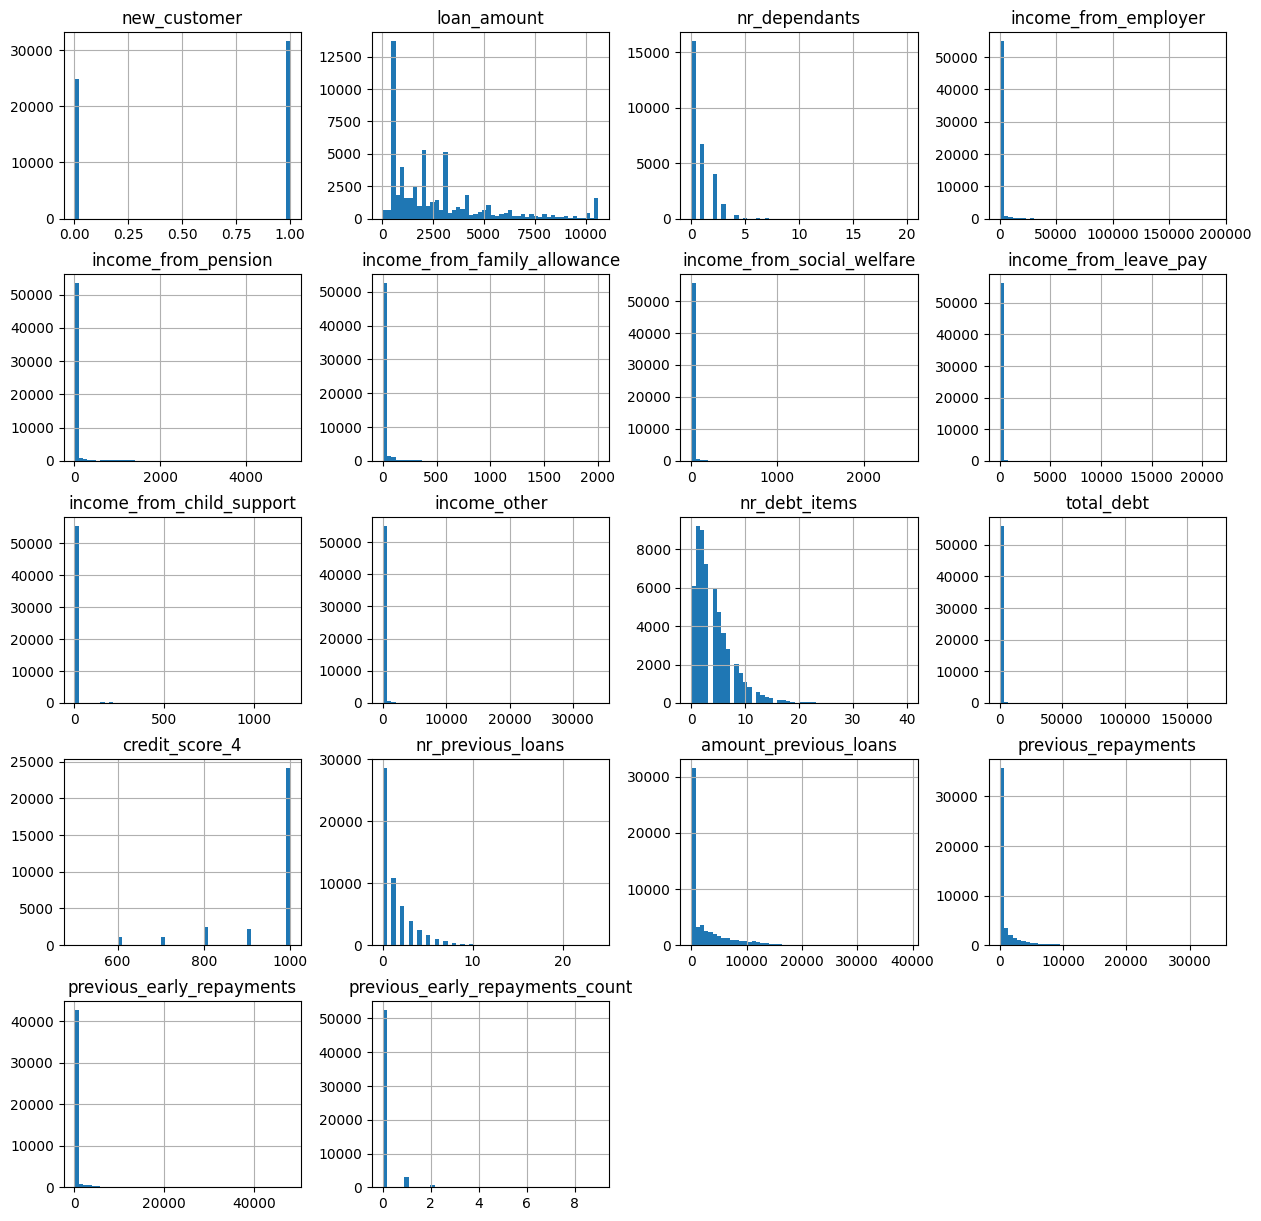

In [65]:
X_train[numerical_variables].hist(bins=50, figsize=(15,15))

plt.show()

### Notes on above histogram
- `new_customer` — binary (0/1), roughly split between new and returning customers
- `loan_amount` — right-skewed, most loans are small amounts with a long tail of larger loans
- `nr_dependants` — heavily concentrated at 0, (which may represents imputed missing values)
- `income_from_employer` — highly right-skewed, most customers have low/zero employer income, with a few high earners
- `income_from_pension`, `income_from_family_allowance`, `income_from_social_welfare`, `income_from_leave_pay`, `income_from_child_support`, `income_other` — all heavily zero-inflated (most customers have no income from these sources)
- `nr_debt_items` — right-skewed, most customers have few debt items
- `total_debt` — right-skewed, most customers have low debt
- `credit_score_4` — bimodal with a large spike at 1000 and another at -1 (missing values imputed as -1)
- `nr_previous_loans` — right-skewed, most customers have 0–2 previous loans
- `amount_previous_loans`, `previous_repayments`, `previous_early_repayments` — all heavily zero-inflated with long right tails
- `previous_early_repayments_count` — almost all values are 0



In [66]:
numerical_variables_na = [var for var in numerical_variables if X_train[var].isnull().sum() > 0]

numerical_variables_na

['nr_dependants',
 'credit_score_4',
 'previous_repayments',
 'previous_early_repayments']

In [67]:
X_train[numerical_variables_na].describe()

,nr_dependants,credit_score_4,previous_repayments,previous_early_repayments
count,28488.000000,31025.000000,48257.000000,45528.000000
mean,0.729254,951.922643,980.815380,260.953051
std,1.026533,103.086680,2327.506222,1399.392338
min,0.000000,500.000000,0.000000,0.000000
25%,0.000000,1000.000000,0.000000,0.000000
50%,0.000000,1000.000000,0.000000,0.000000
75%,1.000000,1000.000000,735.380000,0.000000
max,20.000000,1000.000000,34077.420000,48100.000000


In [68]:
imputation_num_dict = {var: -1 for var in numerical_variables_na}
imputation_num_dict

{'nr_dependants': -1,
 'credit_score_4': -1,
 'previous_repayments': -1,
 'previous_early_repayments': -1}

In [69]:
X_train.fillna(value = imputation_num_dict, inplace=True)
X_test.fillna(value = imputation_num_dict, inplace=True)

,new_customer,application_date,income_verification,language,date_of_birth,gender,country,loan_amount,county,city,...,total_debt,credit_score_1,credit_score_2,credit_score_3,credit_score_4,nr_previous_loans,amount_previous_loans,previous_repayments,previous_early_repayments,previous_early_repayments_count
44608,1,2022-02-19 21:02:31,unverified,estonian,1969-05-09,male,EE,2020.0,Lääne-Viru maakond,Haljala vald,...,17.70,M,NaN,NaN,1000.0,1,530.0,21.34,0.0,0
32034,0,2021-08-20 17:55:44,income_and_expenses_verified,russian,1989-02-11,female,EE,530.0,Ida-Viru maakond,Kohtla-Järve linn,...,354.55,M,NaN,NaN,1000.0,3,11045.0,4026.01,0.0,0
6469,0,2019-07-06 21:30:02,verified,estonian,1983-09-28,male,EE,1500.0,HIIU,HAUSMA,...,350.94,NaN,NaN,NaN,700.0,1,2500.0,499.80,1500.0,1
12433,1,2020-05-17 13:30:34,income_and_expenses_verified,spanish,1978-03-20,male,ES,635.0,GALICIA,OURENSE,...,960.00,M1,B,NaN,-1.0,0,0.0,0.00,0.0,0
35022,1,2021-09-26 14:35:39,income_and_expenses_verified,finnish,1994-07-17,male,FI,2550.0,NaN,KERAVA,...,774.84,M,NaN,5,-1.0,1,3153.0,445.79,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32979,1,2017-06-18 16:18:34,income_and_expenses_verified,estonian,1970-03-11,female,EE,3000.0,VÕRUMAA,VÕRU,...,336.00,NaN,NaN,NaN,-1.0,0,0.0,0.00,0.0,0
31005,1,2021-09-01 18:45:57,income_and_expenses_verified,spanish,1971-12-14,male,ES,530.0,NaN,NaN,...,0.00,M4,B,NaN,-1.0,0,0.0,0.00,0.0,0
30500,0,2016-11-29 11:55:59,income_and_expenses_verified,estonian,1982-11-07,male,EE,750.0,TARTU,KAKUMETSA K. LUUNJA,...,254.00,NaN,NaN,NaN,-1.0,1,2000.0,755.58,0.0,0
67843,1,2018-09-13 08:43:53,verified,estonian,1983-03-23,female,EE,2000.0,TARTU,TARTU,...,444.00,NaN,NaN,NaN,1000.0,0,0.0,0.00,0.0,0


In [70]:
X_test[numerical_variables_na].isnull().sum()

nr_dependants                0
credit_score_4               0
previous_repayments          0
previous_early_repayments    0
dtype: int64

# Create new income and debt based variables
Historically, variables that capture the relationship between the customer's income and existing debt have been very useful to assess the customer's probability of defaulting. These variables are:

- The customer's total income, which is the sum of all income sources
- The debt-to-income ratio, which measures the proportion of income used to pay off existing debt
- The discretionary income, which is the money remaining after paying off the monthly debt.

The CEO and our investors will probably want to see that the model uses these variables as input.

Please go ahead and create those variables from the existing data. The variable total_debt which you will find in the data set, represents the customer's monthly debt. In the data set, you will also find many income-related variables representing the different sources of monthly income for each customer. Keep in mind that our platform does not require customers to enter their income. As a result, you may come across customers whose income is zero because they did not disclose it.

In [71]:
sources_of_income = ['income_from_employer',
    'income_from_pension',
    'income_from_family_allowance',
    'income_from_social_welfare',
    'income_from_leave_pay',
    'income_from_child_support',
    'income_other']

X_train['total_income'] = X_train[sources_of_income].sum(axis=1)
X_test['total_income'] = X_test[sources_of_income].sum(axis=1)


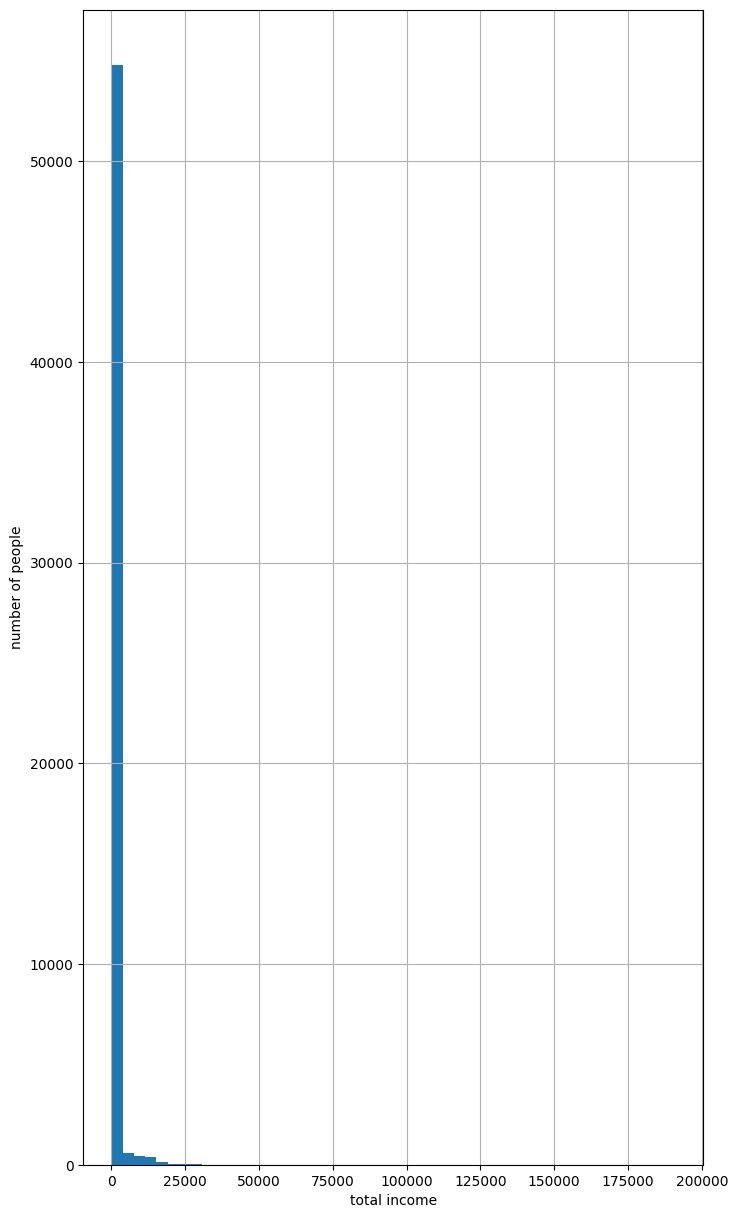

In [72]:
X_train['total_income'].hist(bins=50, figsize=(8,15))
plt.ylabel("number of people")
plt.xlabel("total income")
plt.show()


In [73]:
X_train['debt_to_income_ratio'] = X_train['total_debt'] / X_train['total_income']
X_test['debt_to_income_ratio'] = X_test['total_debt'] / X_test['total_income']

In [74]:
X_train[["debt_to_income_ratio", "total_debt", "total_income"]].head()

,debt_to_income_ratio,total_debt,total_income
11155,0.822736,854.0,1038.0
50730,0.428182,471.0,1100.0
35924,NaN,0.0,0.0
69230,0.299476,286.0,955.0
35679,inf,245.4,0.0


In [75]:
from numpy import nan, inf

X_train['debt_to_income_ratio'] = X_train['debt_to_income_ratio'].replace([inf, nan], 0)
X_test['debt_to_income_ratio'] = X_test['debt_to_income_ratio'].replace([inf, nan], 0)

X_train[["debt_to_income_ratio", "total_debt", "total_income"]].head()

,debt_to_income_ratio,total_debt,total_income
11155,0.822736,854.0,1038.0
50730,0.428182,471.0,1100.0
35924,0.000000,0.0,0.0
69230,0.299476,286.0,955.0
35679,0.000000,245.4,0.0


In [76]:
X_train['cash'] = X_train['total_income'] - X_train['total_debt']
X_test['cash'] = X_test['total_income'] - X_test['total_debt']

X_train[["cash", "total_debt", "total_income"]].head()



,cash,total_debt,total_income
11155,184.0,854.0,1038.0
50730,629.0,471.0,1100.0
35924,0.0,0.0,0.0
69230,669.0,286.0,955.0
35679,-245.4,245.4,0.0


# Create features from datetime variables
When the customer makes a loan application, the date and time of the application are automatically recorded. We also require customers to enter their date of birth so we can use that to retrieve their financial information from the credit agencies.

Our company only provides loans to customers who are at least 18 years old. Younger customers or customers who wrongly enter their date of birth are automatically declined, and their data is not passed to our credit risk model. If you find such customers in the data set, please remove them.

Using the date of application and the date of birth, please return the age of the customer at the time of application. Age could be a good indicator of credit worthiness. Next, please go ahead and create multiple features to represent the date and time of the application, like month, day of the week, etc.



In [77]:
datetime_vars = ["application_date", "date_of_birth"]

X_train[datetime_vars]


,application_date,date_of_birth
11155,2020-03-25 02:42:53,1973-03-28
50730,2017-12-23 12:49:32,1974-02-19
35924,2021-10-14 13:26:08,1975-01-17
69230,2018-11-09 09:37:29,1980-05-28
35679,2021-10-07 10:48:05,1980-04-20
...,...,...
17904,2020-10-31 16:28:11,1962-05-14
37597,2021-11-13 18:03:53,1981-06-07
10201,2019-12-16 13:01:09,1970-05-16
9372,2019-11-10 19:53:33,1989-10-01


In [78]:
X_train[datetime_vars].isnull().sum()

application_date    0
date_of_birth       0
dtype: int64

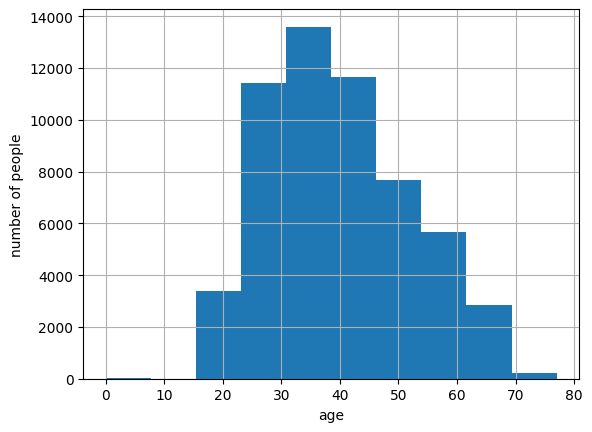

In [79]:
# Age of customer at the time of application

X_train['age'] = ((pd.to_datetime(X_train['application_date']) - pd.to_datetime(X_train['date_of_birth'])).dt.days / 365).astype(int)
X_train['age'].hist()
plt.ylabel("number of people")
plt.xlabel("age")
X_test['age'] = ((pd.to_datetime(X_test['application_date']) - pd.to_datetime(X_test['date_of_birth'])).dt.days / 365).astype(int)

In [80]:
# Remove people younger that 18
X_train = X_train[X_train['age'] >= 18]
X_test = X_test[X_test['age'] >= 18]

# Set target variables
y_train = y_train.loc[X_train.index]
y_test = y_test.loc[X_test.index]

In [81]:
# Create features in train set
X_train["application_date"] = pd.to_datetime(X_train["application_date"])
X_train["day_of_week"] = X_train["application_date"].dt.day_of_week
X_train["day_of_month"] = X_train["application_date"].dt.day
X_train["month"] = X_train["application_date"].dt.month
X_train["hour"] = X_train["application_date"].dt.hour

# Create features in test set
X_test["application_date"] = pd.to_datetime(X_test["application_date"])
X_test["day_of_week"] = X_test["application_date"].dt.day_of_week
X_test["day_of_month"] = X_test["application_date"].dt.day
X_test["month"] = X_test["application_date"].dt.month
X_test["hour"] = X_test["application_date"].dt.hour

X_train[["application_date", "day_of_week", "day_of_month", "month", "hour"]].head(5)

,application_date,day_of_week,day_of_month,month,hour
11155,2020-03-25 02:42:53,2,25,3,2
50730,2017-12-23 12:49:32,5,23,12,12
35924,2021-10-14 13:26:08,3,14,10,13
69230,2018-11-09 09:37:29,4,9,11,9
35679,2021-10-07 10:48:05,3,7,10,10


In [82]:
X_train.drop(["application_date", "date_of_birth"], axis=1, inplace=True)
X_test.drop(["application_date", "date_of_birth"], axis=1, inplace=True)

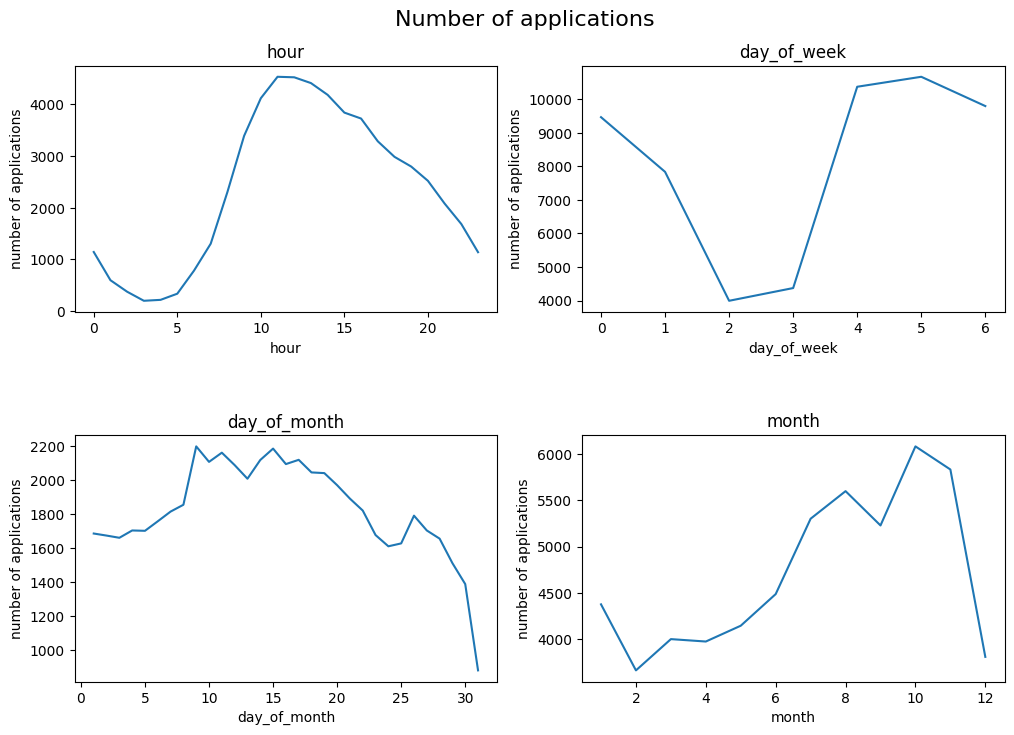

In [83]:
# Define subplot grid
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
plt.subplots_adjust(hspace=0.5)
fig.suptitle("Number of applications", fontsize=16, y=0.95)

new_features = ["hour", "day_of_week", "day_of_month", "month"]
 
# loop through variables and axes
for var, ax in zip(new_features, axs.ravel()):
    
    # Plot the variable
    X_train.groupby(var)[var].count().plot(ax=ax)
 
    # Plot formatting
    ax.set_title(var)
    ax.set_ylabel("number of applications")

# Evaluate categorical variables cardinality
Much of the information we have about our customers comes in the form of strings. For example, gender, marital status, employment and others.

We accept applications from all over Europe. Therefore, some values, like job position, are entered in different languages, and you will see that they have a multitude of unique values. We'd rather not use such variables in our credit risk model because we anticipate future values that are not present in our current data sets, and therefore, the model will not be able to process them.

Please go ahead and find highly cardinal categorical variables and remove them from the data sets.



In [84]:
categorical_variables = [x for x in X_train.select_dtypes(include="O").columns if x not in datetime_vars]

categorical_variables

/var/folders/_w/8s1fvxhj4_l2qm__16dyrbbm0000gn/T/ipykernel_7400/1618054912.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_variables = [x for x in X_train.select_dtypes(include="O").columns if x not in datetime_vars]


['income_verification',
 'language',
 'gender',
 'country',
 'county',
 'city',
 'use_of_loan',
 'education',
 'marital_status',
 'employment_status',
 'employment_duration',
 'employment_position',
 'work_experience',
 'occupation',
 'home_ownership',
 'credit_score_1',
 'credit_score_2',
 'credit_score_3']

In [85]:
X_train[categorical_variables].head(5)

,income_verification,language,gender,country,county,city,use_of_loan,education,marital_status,employment_status,employment_duration,employment_position,work_experience,occupation,home_ownership,credit_score_1,credit_score_2,credit_score_3
11155,unverified,spanish,female,ES,CATALUNYA,LLEIDA,loan_consolidation,secondary,divorced,retiree,UpTo5Years,Worker,15To25Years,other,tenant_furnished,M1,B,NaN
50730,income_and_expenses_verified,spanish,female,ES,MADRID,MADRID,other,higher,single,fully,UpTo5Years,telefonioperaator,15To25Years,telecom,tenant_furnished,M1,B,NaN
35924,income_and_expenses_verified,russian,male,EE,Harju maakond,Tallinn,unknown,higher,NaN,NaN,UpTo5Years,NaN,NaN,NaN,owner,M,NaN,NaN
69230,income_and_expenses_verified,estonian,male,EE,HARJU,TALLINN,vehicle,secondary,single,fully,UpTo2Years,Executive,10To15Years,construction,tenant_furnished,NaN,NaN,NaN
35679,unverified,russian,male,EE,Harju maakond,Tallinn,unknown,secondary,NaN,NaN,MoreThan5Years,NaN,NaN,NaN,owner,M,NaN,NaN


<Axes: >

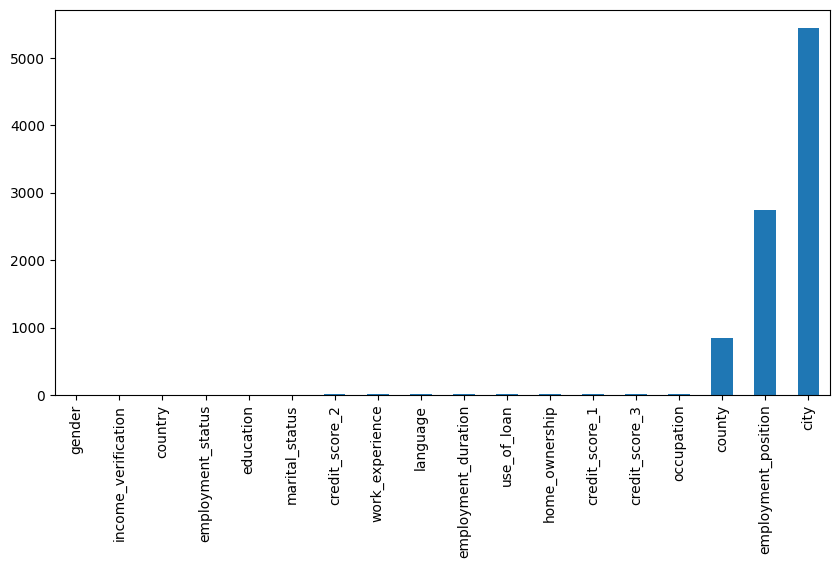

In [86]:
# Number of unique categories per variable
X_train[categorical_variables].nunique().sort_values(ascending=True).plot.bar(figsize=(10,5))

In [87]:
highly_cardinal_variables = ["employment_position", "city", "county"]
 
for var in highly_cardinal_variables:
    print(var)
    print(X_train[var].unique()[0:10])
    print()

employment_position
<ArrowStringArray>
[                                  'Worker',
                        'telefonioperaator',
                                        nan,
                                'Executive',
                            'MiddleManager',
                   'SpecialistOfficeWorker',
                                 'Camarero',
 'müügisekretär  ( hetkel kodune lapsega) ',
                                   'Jurist',
                               'Autopesija']
Length: 10, dtype: str

city
<ArrowStringArray>
[         'LLEIDA',          'MADRID',         'Tallinn',         'TALLINN',
               nan, 'Tahkuranna vald',      'Põlva vald',          'MÁLAGA',
        'PALDISKI',            'PORI']
Length: 10, dtype: str

county
<ArrowStringArray>
[    'CATALUNYA',        'MADRID', 'Harju maakond',         'HARJU',
             nan, 'Pärnu maakond', 'Põlva maakond',     'ANDALUCÍA',
      'VALENCIA',       'VÕRUMAA']
Length: 10, dtype: str



In [88]:
X_train.drop(highly_cardinal_variables, axis=1, inplace=True)
X_test.drop(highly_cardinal_variables, axis=1, inplace=True)

# Impute categorical variables
Please determine if the categorical variables contain missing data and, if so, impute them.

In [89]:
categorical_variables = [var for var in categorical_variables if var not in highly_cardinal_variables]

categorical_variables_na = [var for var in categorical_variables if X_train[var].isnull().sum() > 0 ]
categorical_variables_na

['gender',
 'education',
 'marital_status',
 'employment_status',
 'employment_duration',
 'work_experience',
 'occupation',
 'home_ownership',
 'credit_score_1',
 'credit_score_2',
 'credit_score_3']

In [90]:
imputation_categorical_dict = {var: "missing" for var in categorical_variables_na}
imputation_categorical_dict

{'gender': 'missing',
 'education': 'missing',
 'marital_status': 'missing',
 'employment_status': 'missing',
 'employment_duration': 'missing',
 'work_experience': 'missing',
 'occupation': 'missing',
 'home_ownership': 'missing',
 'credit_score_1': 'missing',
 'credit_score_2': 'missing',
 'credit_score_3': 'missing'}

In [91]:
# Impute missing data
X_train.fillna(value=imputation_categorical_dict, inplace=True)
X_test.fillna(value=imputation_categorical_dict, inplace=True)

X_test[categorical_variables_na].isnull().sum()

gender                 0
education              0
marital_status         0
employment_status      0
employment_duration    0
work_experience        0
occupation             0
home_ownership         0
credit_score_1         0
credit_score_2         0
credit_score_3         0
dtype: int64

# Group infrequent categories
Some of the categorical variables accept values that are very rare. For example, our main customer base speaks Estonian, Finnish, Spanish, and Russian. But since we do accept applications from all over Europe, some other languages can also be taken as input. As a result, only a small percentage of customers speak languages other than those listed above. And in addition, future customers may speak a language that we currently do not have in our data set. Thus, we would like to group infrequent values into one single category, called "rare."

Please group categories that are present in less than 5% of the observations into a single value for the following variables:

- language
- use_of_loan
- occupation
- home_ownership
- credit_score_1
- credit_score_2
- credit_score_3

In [92]:
variable_groups = [
    'language',
    'use_of_loan',
    'occupation',
    'home_ownership',
    'credit_score_1',
    'credit_score_2',
    'credit_score_3',
]

frequent_categories_dictionary = {}

for var in variable_groups:
    # Calculate the frequency of each category
    freq = X_train[var].value_counts(normalize=True)
    # Select the frequent categories
    frequent = freq[freq >= 0.05].index.tolist()
    # Store the frequent categories in the dictionary
    frequent_categories_dictionary[var] = frequent

frequent_categories_dictionary

{'language': ['estonian', 'finnish', 'spanish', 'russian'],
 'use_of_loan': ['unknown', 'other', 'home_improvement', 'loan_consolidation'],
 'occupation': ['missing', 'other', 'retail'],
 'home_ownership': ['owner',
  'tenant_furnished',
  'living_with_parents',
  'mortgage',
  'tenant_unfurnished'],
 'credit_score_1': ['missing', 'M', 'M1'],
 'credit_score_2': ['missing', 'B'],
 'credit_score_3': ['missing', 'RL2']}

In [93]:
for var in variable_groups:
    # Replace infrequent categories with "rare"
    X_train[var] = np.where(X_train[var].isin(frequent_categories_dictionary[var]), X_train[var], "rare")
    X_test[var] = np.where(X_test[var].isin(frequent_categories_dictionary[var]), X_test[var], "rare")

X_test["language"].value_counts(normalize=True)

language
estonian    0.541959
finnish     0.184973
spanish     0.166277
russian     0.093336
rare        0.013455
Name: proportion, dtype: float64

# Encode categorical variables
The Python implementation of lightGBM does not support strings as values. So you need to replace the category values of categorical variables with numbers.

In [94]:
encoder = OrdinalEncoder()

encoder.fit(X_train[categorical_variables])

X_train[categorical_variables] = encoder.transform(X_train[categorical_variables])
X_test[categorical_variables] = encoder.transform(X_test[categorical_variables])

X_train[categorical_variables].head(5)

,income_verification,language,gender,country,use_of_loan,education,marital_status,employment_status,employment_duration,work_experience,occupation,home_ownership,credit_score_1,credit_score_2,credit_score_3
11155,1.0,4.0,0.0,1.0,1.0,4.0,1.0,4.0,8.0,1.0,1.0,4.0,1.0,0.0,1.0
50730,0.0,4.0,0.0,1.0,2.0,1.0,4.0,1.0,8.0,1.0,2.0,4.0,1.0,0.0,1.0
35924,0.0,3.0,1.0,0.0,4.0,1.0,3.0,2.0,8.0,6.0,0.0,2.0,0.0,1.0,1.0
69230,0.0,0.0,1.0,0.0,3.0,4.0,4.0,1.0,5.0,0.0,2.0,4.0,2.0,1.0,1.0
35679,1.0,3.0,1.0,0.0,4.0,4.0,3.0,2.0,0.0,6.0,0.0,2.0,0.0,1.0,1.0


In [95]:
joblib.dump(encoder, "encoder.pkl")

['encoder.pkl']

# Train and evaluate a lightGBM
Now that you have a fully preprocessed dataset containing transformed and new features, please go ahead and train and evaluate a lightGBM model.

Using the Python API for lightGBM, set up and train a lightGBM model. To speed up training, use callbacks to stop the training if the performance does not improve after 3 iterations. Collect the training results in a dictionary so you can determine if the learning converged.

To evaluate the model, please use the ROC-AUC and also create a full classification report containing the precision, recall, f1-score, and accuracy values.

In [96]:
gbm = lgb.LGBMClassifier(
    num_iterations=1000,
    random_state=seed,
)

evaluation_results = {}


In [97]:
gbm.fit(
    X_train,
    y_train,
    eval_set = [(X_test, y_test)],
    categorical_feature=categorical_variables,
    callbacks=[
        lgb.early_stopping(3),
        lgb.record_evaluation(evaluation_results)
    ]
)

[LightGBM] [Info] Number of positive: 37116, number of negative: 19373
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002986 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3737
[LightGBM] [Info] Number of data points in the train set: 56489, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.657048 -> initscore=0.650168
[LightGBM] [Info] Start training from score 0.650168
Training until validation scores don't improve for 3 rounds
Early stopping, best iteration is:
[114]	valid_0's binary_logloss: 0.567278


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


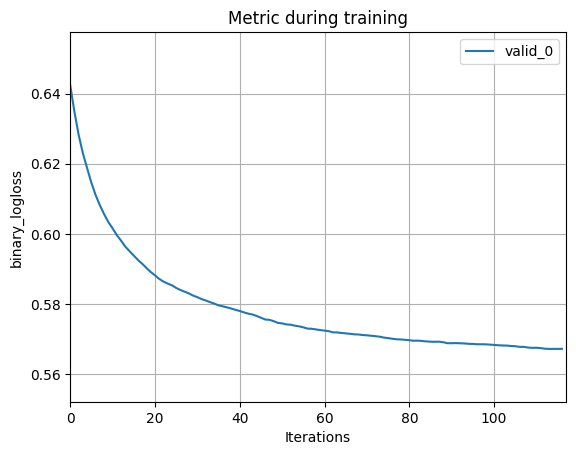

In [98]:
ax = lgb.plot_metric(evaluation_results, metric='binary_logloss')
 
plt.show()


The values of the binary log loss obtained after each iteration of training the lightGBM. The values reach a plateau at higher iterations, suggesting that the learning converged at a minimum of the optimization function.

In [99]:
predict_train = gbm.predict_proba(X_train)[:, 1]
predict_test = gbm.predict_proba(X_test)[:, 1]


In [100]:
roc_train = roc_auc_score(y_train, predict_train)
print(f"Train set roc-auc: {roc_train}")
roc_test = roc_auc_score(y_test, predict_test)
print(f"Eval set roc-auc: {roc_test}")


Train set roc-auc: 0.7922777480356854
Eval set roc-auc: 0.7376127137927155


In [101]:
# Predict if customer will default
predict_train = gbm.predict(X_train)
predict_test = gbm.predict(X_test)


In [104]:
# Classification report
classification_report_train = classification_report(y_train, predict_train)
print(classification_report_train)
classification_report_test = classification_report(y_test, predict_test)
print(classification_report_test)


              precision    recall  f1-score   support

           0       0.72      0.43      0.54     19373
           1       0.75      0.91      0.83     37116

    accuracy                           0.75     56489
   macro avg       0.74      0.67      0.68     56489
weighted avg       0.74      0.75      0.73     56489

              precision    recall  f1-score   support

           0       0.65      0.38      0.48      5034
           1       0.72      0.89      0.80      9087

    accuracy                           0.71     14121
   macro avg       0.69      0.63      0.64     14121
weighted avg       0.70      0.71      0.68     14121



In [105]:
joblib.dump(gbm, "lightGBM.pkl")

['lightGBM.pkl']

# Evaluate feature importance
We'd like to understand which features are useful to predict credit risk. To get a broad overview of feature importance, we'd like to evaluate features with more than one method. To begin, please determine the feature importance returned by the lightGBM. Then evaluate the feature's importance by permutation. This method consists of randomly shuffling the values of each feature, one at a time, then obtaining predictions utilizing the shuffled feature and determining the drop in performance, if any, caused by the permutation.

Finally, train single-feature classifiers and determine if each feature, individually, returns a model that outputs predictions that are better than returning a random guess. Use simple decision trees as classifiers, and the ROC-AUC as a performance metric.

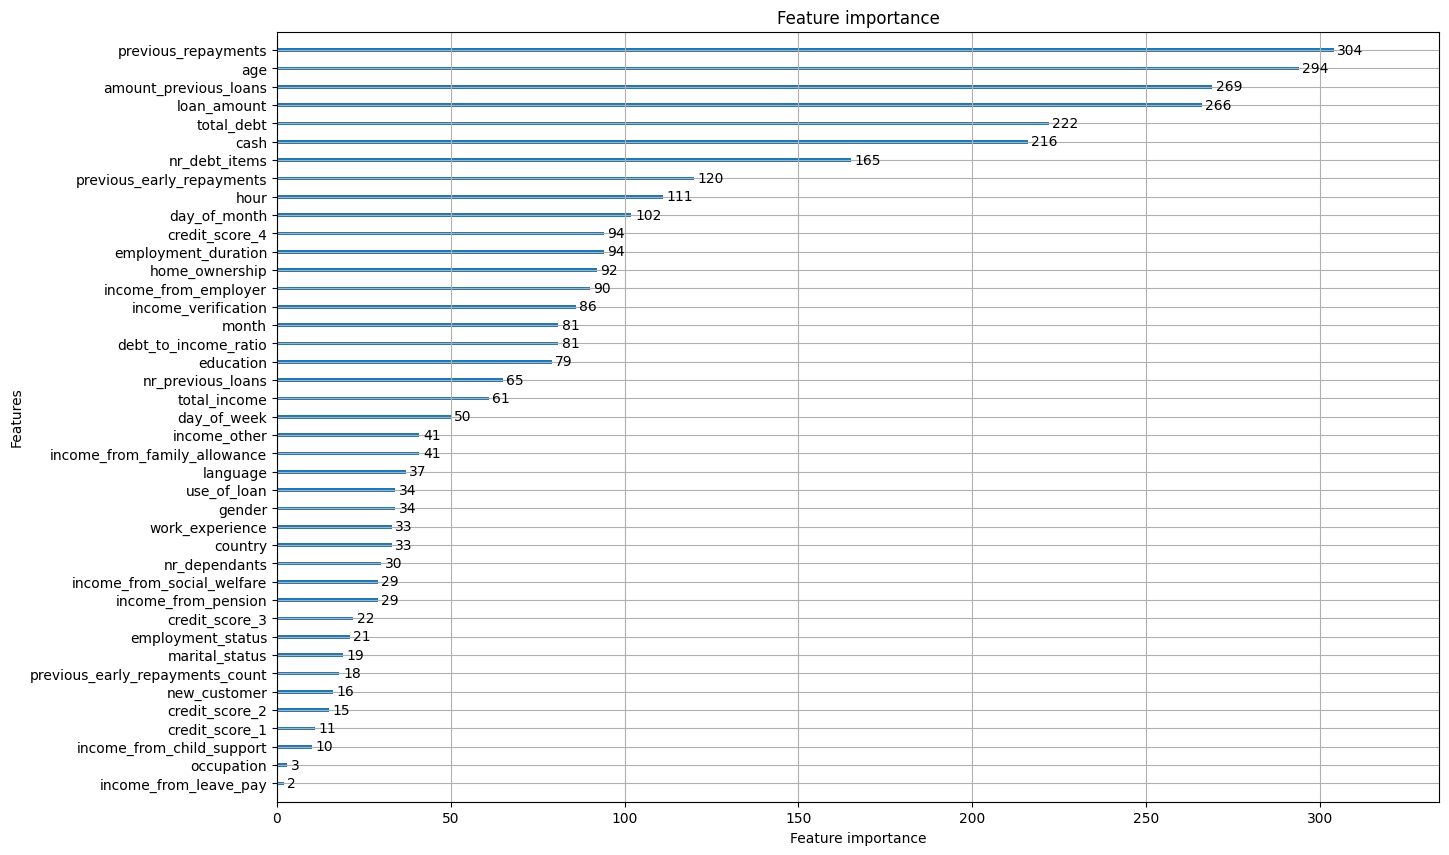

In [106]:
feature_importance = lgb.plot_importance(gbm, figsize=(15, 10))
plt.show()

In [109]:
# Determine the drop in performance generated by randomly shuffling the values of each feature.
# Helps identify truly important feature(s) 
result = permutation_importance(
    gbm,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=3,
    random_state=seed,
)

Text(0, 0.5, 'permutation importance')

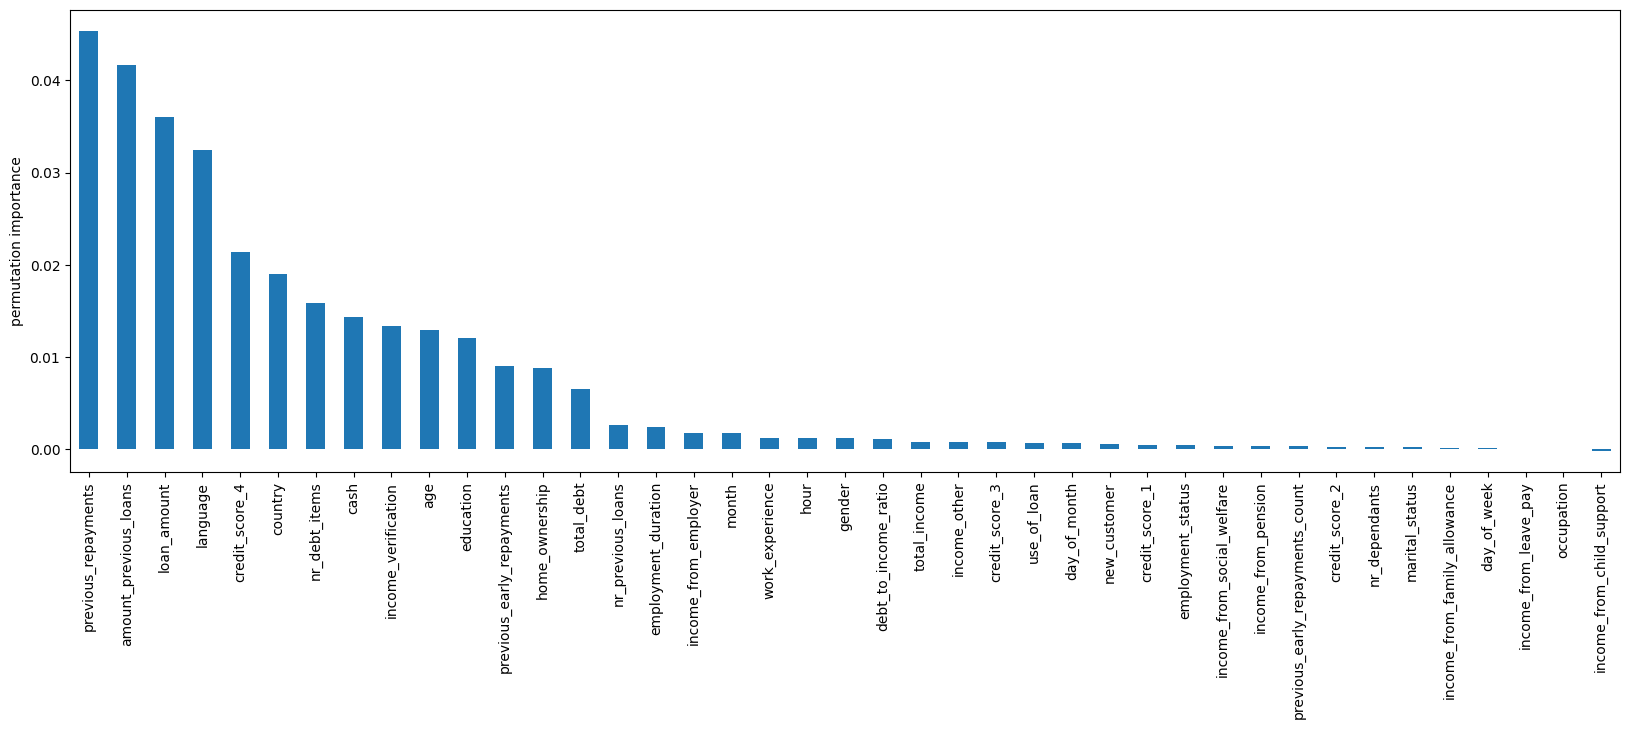

In [110]:
result = pd.Series(result.importances_mean, index=X_train.columns)
result.sort_values(ascending=False).plot.bar(figsize=(20, 6))
plt.ylabel("permutation importance")


In [112]:
# all features that caused any drop in performance when shuffled:

feature_subset_1 = list((result>0).index)
print(len(feature_subset_1))
feature_subset_1


41


['new_customer',
 'income_verification',
 'language',
 'gender',
 'country',
 'loan_amount',
 'use_of_loan',
 'education',
 'marital_status',
 'nr_dependants',
 'employment_status',
 'employment_duration',
 'work_experience',
 'occupation',
 'home_ownership',
 'income_from_employer',
 'income_from_pension',
 'income_from_family_allowance',
 'income_from_social_welfare',
 'income_from_leave_pay',
 'income_from_child_support',
 'income_other',
 'nr_debt_items',
 'total_debt',
 'credit_score_1',
 'credit_score_2',
 'credit_score_3',
 'credit_score_4',
 'nr_previous_loans',
 'amount_previous_loans',
 'previous_repayments',
 'previous_early_repayments',
 'previous_early_repayments_count',
 'total_income',
 'debt_to_income_ratio',
 'cash',
 'age',
 'day_of_week',
 'day_of_month',
 'month',
 'hour']

41 input features - This means that shuffling every single feature in the test set, caused a decrease in the observed performance. Hence, all features are important:



In [114]:
decision_tree_classifier = DecisionTreeClassifier(random_state=seed)
result={}

In [121]:
# Create a classifier that takes every single feature as input, and evaluate its performance using the ROC-AUC as metric with cross-validation
for feature in X_train.columns:
    cv_score = cross_validate(
        decision_tree_classifier,
        X_train[feature].to_frame(),
        y_train,
        cv=5,
        scoring="roc_auc"
    )

    result[feature]=cv_score['test_score'].mean()

Text(0, 0.5, 'permutation importance')

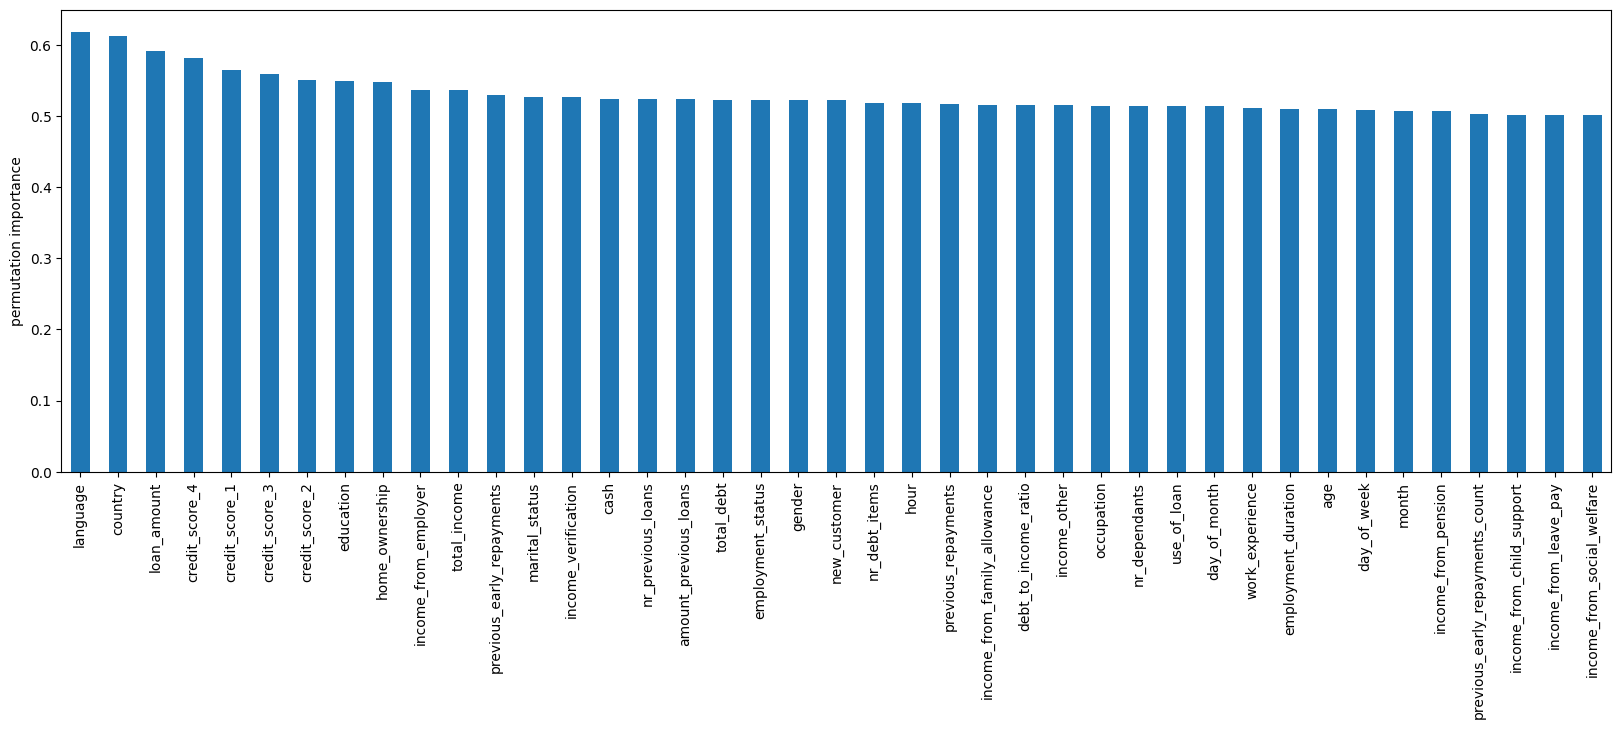

In [122]:
# ROC-AUC returned by every single feature classifier

result_series = pd.Series(result)
result_series.sort_values(ascending=False).plot.bar(figsize=(20, 6))
plt.ylabel("permutation importance")


In [123]:
# Are there features that returned random classifiers

feature_subset_2 = list((result>0.5).index)
print(len(feature_subset_2))


41


Every feature returned a decision tree whose ROC-AUC was greater than 0.5. ROC-AUC values of 0.5 represent random guesses. Hence, using single feature classifiers we corroborate that all features are important to assess credit risk.

# Create an end-to-end feature engineering pipeline
Well done! We are very impressed with your job.

Could we ask you one last thing? Please put all your feature transformation and creation steps in a clean pipeline that we could use to score any data set or data coming through our platform whenever a customer creates a loan application.

The basic idea of the pipeline is that it takes the raw data and returns a fully preprocessed data set with input features ready to be used by the lightGBM to make the predictions.

Please start on a clean notebook so that we can have a clean copy of the entire pipeline to smooth deployment later on.

# Evaluate a cohort of recent customers
Actually, could we ask you one more thing?

We've got another data set with information about our most recent customer applications. To be fully confident that the model continues to have good performance on recent customer cohorts, could you please obtain the predictions of credit risk for these customers as well?

We've placed the raw data, as it comes through our platform, in a file called latest_customers.csv at the root of your workspace. The dataset also contains the target variable default.

Please pass this data through your pipeline, obtain the model predictions, and then evaluate the model's performance.

One thing to notice is that, as these customers have just gotten their loans, we do not have enough history to accurately determine if they are going to default in the near future. As a result, we most likely labeled customers as "no default", even though they may likely default in the coming months. Hence, if the performance metrics are a bit lower than observed, don't worry. As the maturity of the loans develops, we will be able to better assess their performance in the coming months.